In [4]:
import boto3
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sagemaker
import seaborn as sns
from pyathena import connect
from scipy import stats

sagemaker.config INFO - Not applying SDK defaults from location: C:\ProgramData\sagemaker\sagemaker\config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: C:\Users\dcode\AppData\Local\sagemaker\sagemaker\config.yaml


In [5]:
# Set up plotting style
plt.rcParams['figure.figsize'] = (12, 8)

In [6]:
# Connect to AWS services
print("Connecting to AWS services...")
session = boto3.session.Session()
region = session.region_name
sagemaker_session = sagemaker.Session()
bucket = sagemaker_session.default_bucket()

Connecting to AWS services...


In [7]:
# Define paths
S3_DATA_PATH = f"s3://{bucket}/final_project/data"
ATHENA_DB_NAME = "final_project"
S3_STAGING_DIR = f"s3://{bucket}/final_project/staging"
DATA_TABLE_NAME = "ddos_data"

In [8]:
# Connect to Athena
conn = connect(region_name=region, s3_staging_dir=S3_STAGING_DIR)

Connecting to Athena...


In [11]:
# Query to get basic information about the dataset
query = f"""
SELECT COUNT(*) as total_records,
       COUNT(DISTINCT label) as unique_labels,
       COUNT(CASE WHEN label = 'Benign' THEN 1 END) as benign_count,
       COUNT(CASE WHEN label = 'DDoS' THEN 1 END) as ddos_count
FROM {ATHENA_DB_NAME}.{DATA_TABLE_NAME}
"""
df_info = pd.read_sql(query, conn)
print("\nDataset Information:")
print(df_info)

Querying dataset information...


C:\Users\dcode\AppData\Local\Temp\ipykernel_4620\4181313236.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_info = pd.read_sql(query, conn)



Dataset Information:
   total_records  unique_labels  benign_count  ddos_count
0         221264              2         93250      128014


In [18]:
# Query to get a sample of the data
query = f"""
SELECT *
FROM {ATHENA_DB_NAME}.{DATA_TABLE_NAME}
"""
df_full = pd.read_sql(query, conn)
df_full.head(5)

C:\Users\dcode\AppData\Local\Temp\ipykernel_4620\1827577732.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_full = pd.read_sql(query, conn)


,protocol,flow_duration,total_fwd_packets,total_backward_packets,fwd_packets_length_total,bwd_packets_length_total,fwd_packet_length_max,fwd_packet_length_min,fwd_packet_length_mean,fwd_packet_length_std,...,fwd_seg_size_min,active_mean,active_std,active_max,active_min,idle_mean,idle_std,idle_max,idle_min,label
0,6,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
1,6,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
2,6,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
3,6,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
4,6,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign


In [49]:
# Basic stats for features
df_full.describe()

,protocol,flow_duration,total_fwd_packets,total_backward_packets,fwd_packets_length_total,bwd_packets_length_total,fwd_packet_length_max,fwd_packet_length_min,fwd_packet_length_mean,fwd_packet_length_std,...,fwd_act_data_packets,fwd_seg_size_min,active_mean,active_std,active_max,active_min,idle_mean,idle_std,idle_max,idle_min
count,221264.000000,2.212640e+05,221264.000000,221264.000000,221264.000000,2.212640e+05,221264.000000,221264.000000,221264.000000,221264.000000,...,221264.000000,221264.000000,2.212640e+05,2.212640e+05,2.212640e+05,2.212640e+05,2.212640e+05,2.212640e+05,2.212640e+05,2.212640e+05
mean,7.541918,1.657047e+07,4.931069,4.647882,957.074635,6.079700e+03,548.650585,28.086141,167.591393,218.959006,...,3.358260,21.425320,1.885692e+05,1.319630e+04,2.122990e+05,1.812172e+05,1.053111e+07,3.685091e+06,1.313886e+07,7.912344e+06
std,3.822113,3.175633e+07,15.571754,21.967669,3279.604385,3.960443e+04,1881.396181,164.913297,509.459068,804.764057,...,12.387349,4.090044,8.055263e+05,2.123841e+05,9.088130e+05,7.917502e+05,2.202330e+07,1.287496e+07,2.712944e+07,1.999987e+07
min,0.000000,-1.000000e+00,1.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,6.000000,9.032200e+04,2.000000,1.000000,26.000000,0.000000e+00,6.000000,0.000000,6.000000,0.000000,...,1.000000,20.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,6.000000,1.614922e+06,3.000000,4.000000,30.000000,1.680000e+02,20.000000,0.000000,8.666667,5.301991,...,2.000000,20.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,6.000000,9.018368e+06,5.000000,6.000000,62.000000,1.160100e+04,35.000000,6.000000,32.187500,10.263203,...,4.000000,20.000000,1.984000e+03,0.000000e+00,1.984000e+03,1.983000e+03,8.550638e+06,0.000000e+00,8.568788e+06,7.595869e+06
max,17.000000,1.199999e+08,1932.000000,2942.000000,183012.000000,5.172346e+06,11680.000000,1472.000000,3867.000000,6692.645000,...,1931.000000,52.000000,1.000000e+08,3.950000e+07,1.000000e+08,1.000000e+08,1.200000e+08,6.530000e+07,1.200000e+08,1.200000e+08


In [50]:
# Class distribution
print("\nAnalyzing class distribution...")
class_distribution = df_full['label'].value_counts()
print("\nClass distribution in sample:")
print(class_distribution)


Analyzing class distribution...

Class distribution in sample:
label
DDoS      128014
Benign     93250
Name: count, dtype: int64


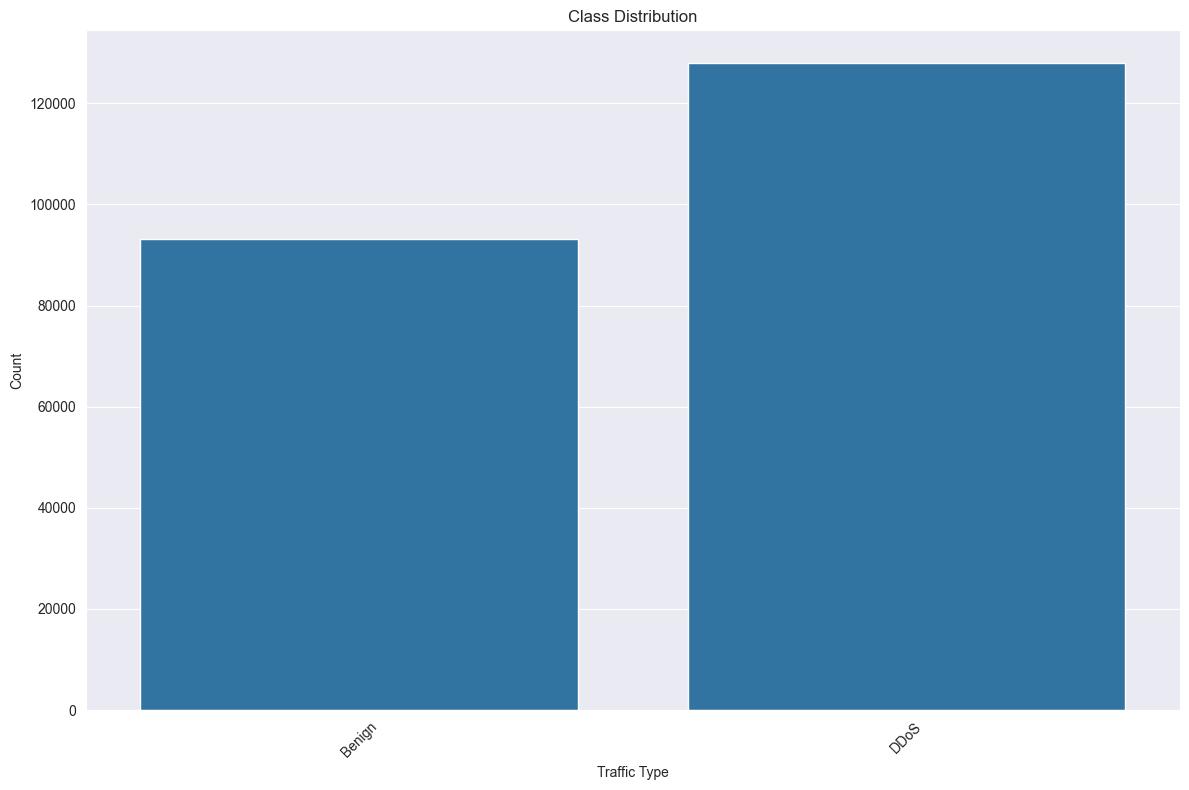

In [51]:
sns.countplot(x='label', data=df_full)
plt.title('Class Distribution')
plt.xlabel('Traffic Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()

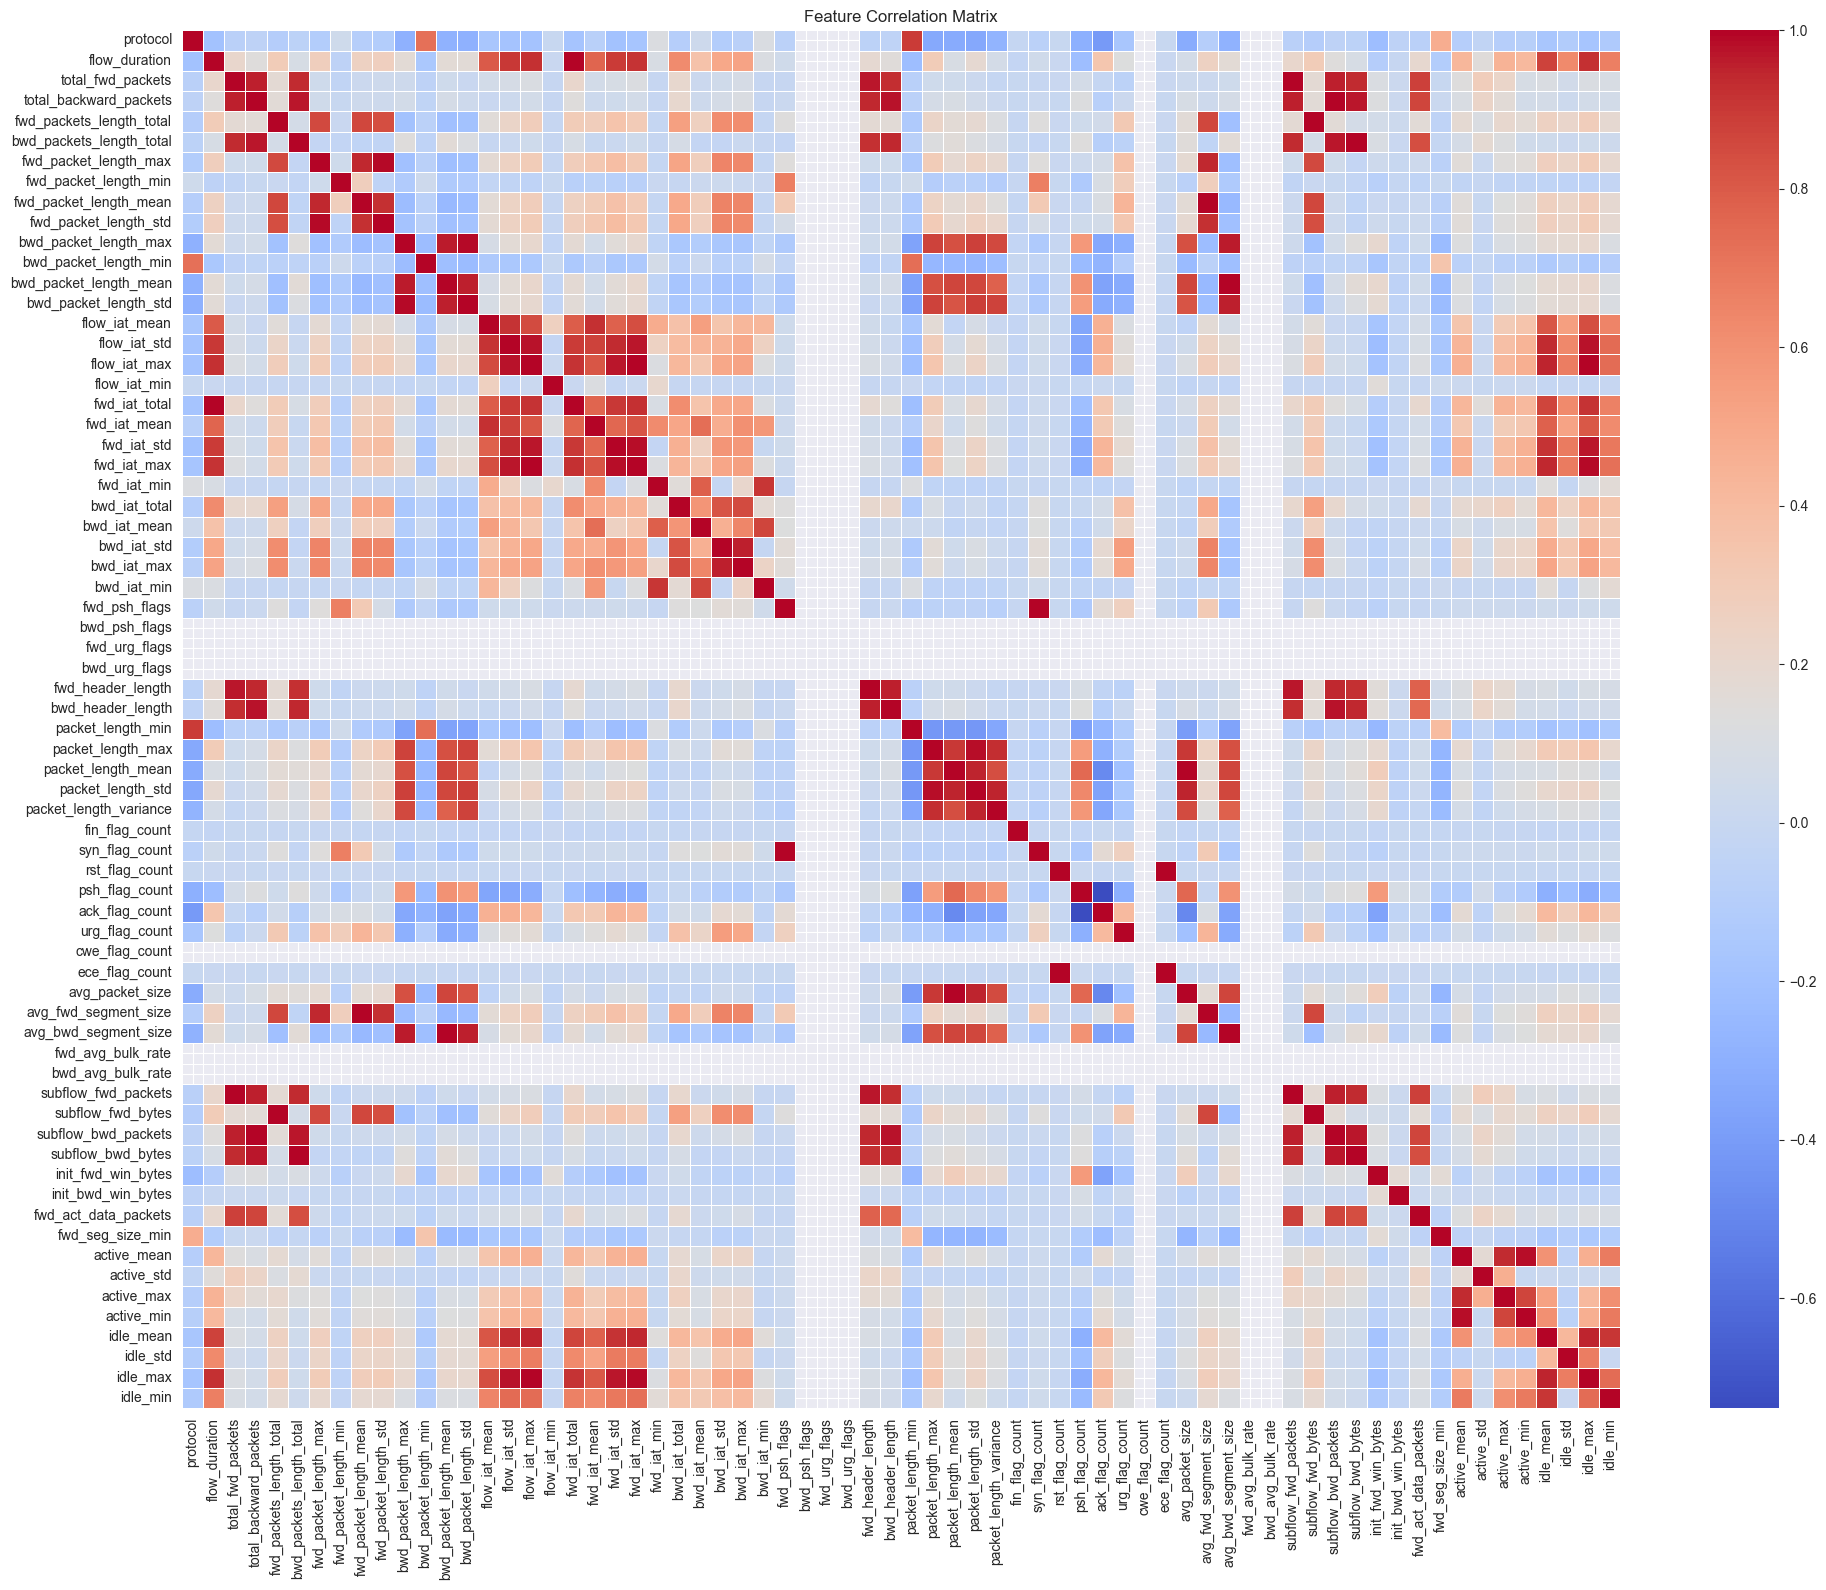

In [52]:
# Feature correlation
numeric_columns = df_full.select_dtypes(include=['int64', 'float64']).columns
correlation_matrix = df_full[numeric_columns].corr()

plt.figure(figsize=(20, 16))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.tight_layout()

In [53]:
# List highly correlated features
high_corr = (correlation_matrix.abs() > 0.8) & (correlation_matrix != 1.0)
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):
        if high_corr.iloc[i, j]:
            high_corr_pairs.append(
                (correlation_matrix.columns[i], correlation_matrix.columns[j], correlation_matrix.iloc[i, j]))

high_corr_pairs_sorted = sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True)
print("\nHighly correlated features:")
for pair in high_corr_pairs_sorted:
    print(f"{pair[0]} and {pair[1]}: {pair[2]:.3f}")


Highly correlated features:
packet_length_mean and avg_packet_size: 0.999
flow_iat_max and idle_max: 0.997
flow_duration and fwd_iat_total: 0.997
flow_iat_max and fwd_iat_max: 0.995
fwd_iat_max and idle_max: 0.993
bwd_packet_length_max and bwd_packet_length_std: 0.993
fwd_packet_length_max and fwd_packet_length_std: 0.992
packet_length_max and packet_length_std: 0.984
active_mean and active_min: 0.983
fwd_iat_std and fwd_iat_max: 0.980
flow_iat_std and flow_iat_max: 0.978
flow_iat_std and idle_max: 0.976
total_backward_packets and bwd_header_length: 0.976
bwd_header_length and subflow_bwd_packets: 0.976
flow_iat_max and fwd_iat_std: 0.972
total_backward_packets and bwd_packets_length_total: 0.970
total_backward_packets and subflow_bwd_bytes: 0.970
bwd_packets_length_total and subflow_bwd_packets: 0.970
subflow_bwd_packets and subflow_bwd_bytes: 0.970
fwd_iat_std and idle_max: 0.970
flow_iat_std and fwd_iat_max: 0.969
total_fwd_packets and fwd_header_length: 0.968
fwd_header_length and

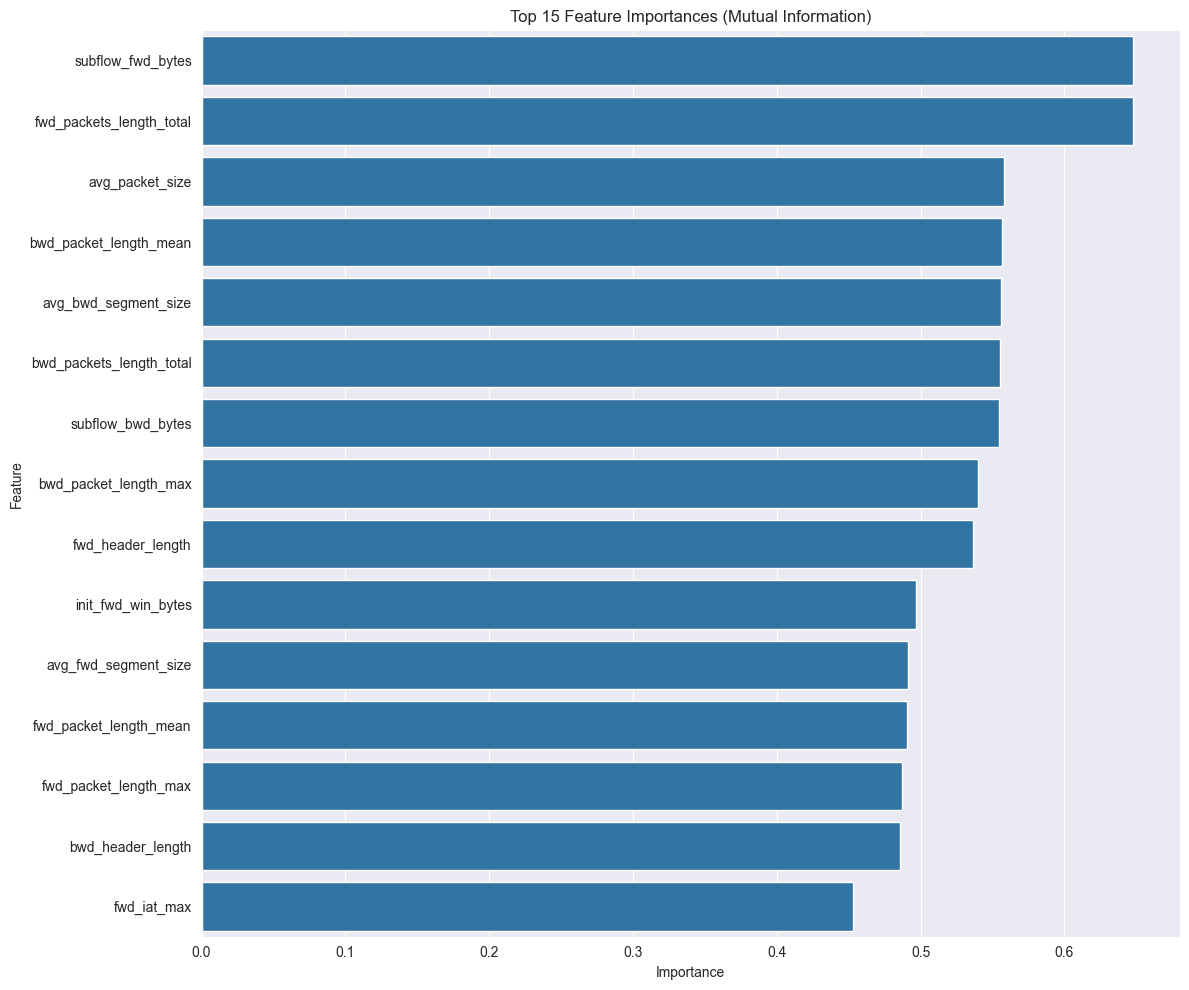

In [54]:
# Plot feature importances
plt.figure(figsize=(12, 10))
sns.barplot(x='Importance', y='Feature', data=feature_importances.head(15))
plt.title('Top 15 Feature Importances (Mutual Information)')
plt.tight_layout()

In [55]:
# Feature variance
feature_variance = pd.DataFrame({
    'Feature': X.columns,
    'Variance': X.var().values
}).sort_values('Variance', ascending=False)

print("\nTop 15 features with highest variance:")
print(feature_variance.head(15))


Top 15 features with highest variance:
          Feature      Variance
18  fwd_iat_total  1.014419e+15
1   flow_duration  1.008464e+15
21    fwd_iat_max  7.674442e+14
66       idle_max  7.360067e+14
16   flow_iat_max  7.236631e+14
23  bwd_iat_total  4.922181e+14
64      idle_mean  4.850257e+14
67       idle_min  3.999947e+14
26    bwd_iat_max  2.666186e+14
65       idle_std  1.657645e+14
20    fwd_iat_std  1.181443e+14
15   flow_iat_std  5.891144e+13
19   fwd_iat_mean  3.580059e+13
25    bwd_iat_std  3.053780e+13
24   bwd_iat_mean  2.144227e+13


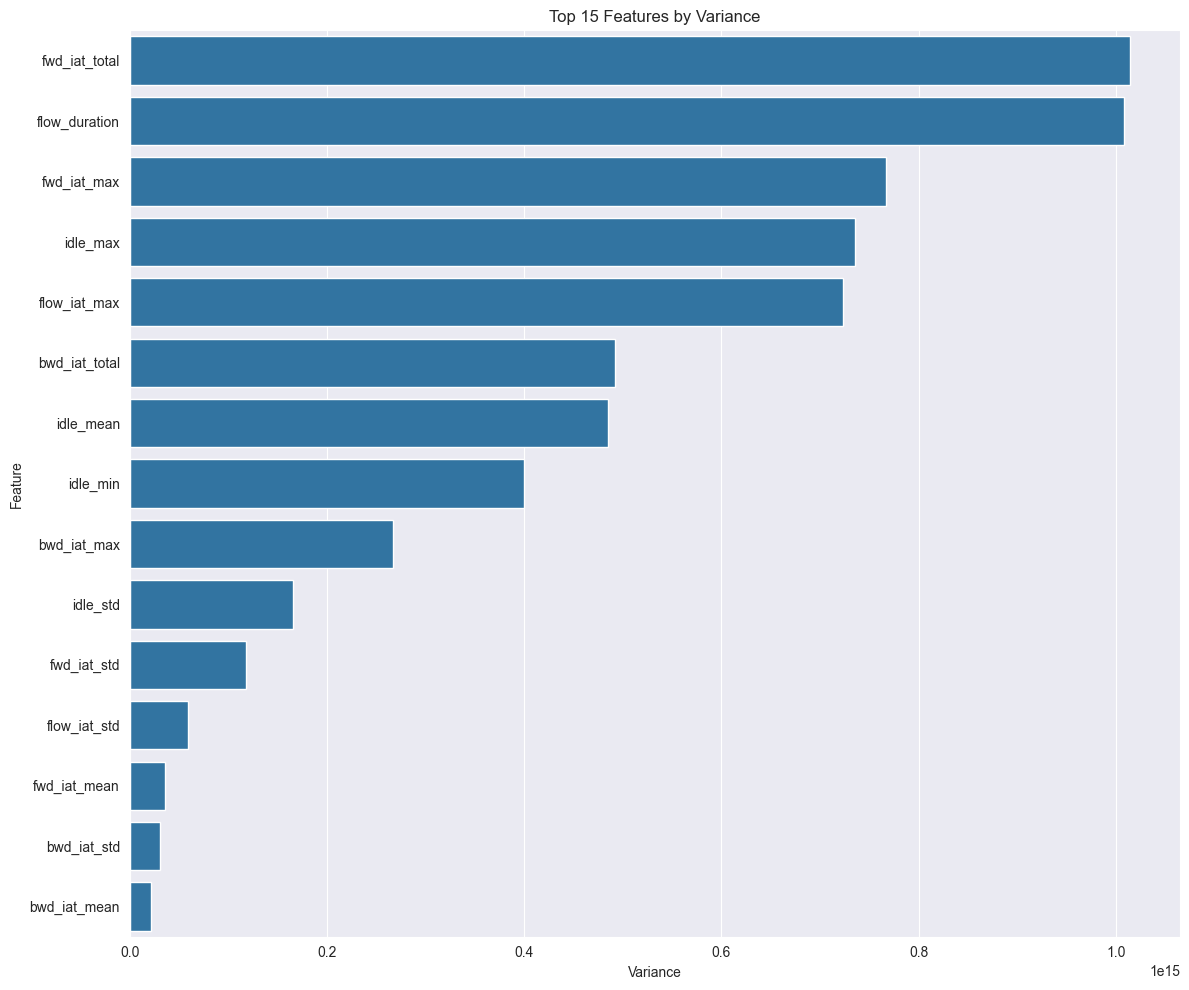

In [56]:
# Plot feature variance
plt.figure(figsize=(12, 10))
sns.barplot(x='Variance', y='Feature', data=feature_variance.head(15))
plt.title('Top 15 Features by Variance')
plt.tight_layout()

In [57]:
# Protocol distribution analysis
print("\nAnalyzing protocol distribution...")
protocol_counts = df_full['protocol'].value_counts()
print("\nProtocol distribution in sample:")
print(protocol_counts)


Analyzing protocol distribution...

Protocol distribution in sample:
protocol
6     190165
17     31045
0         54
Name: count, dtype: int64


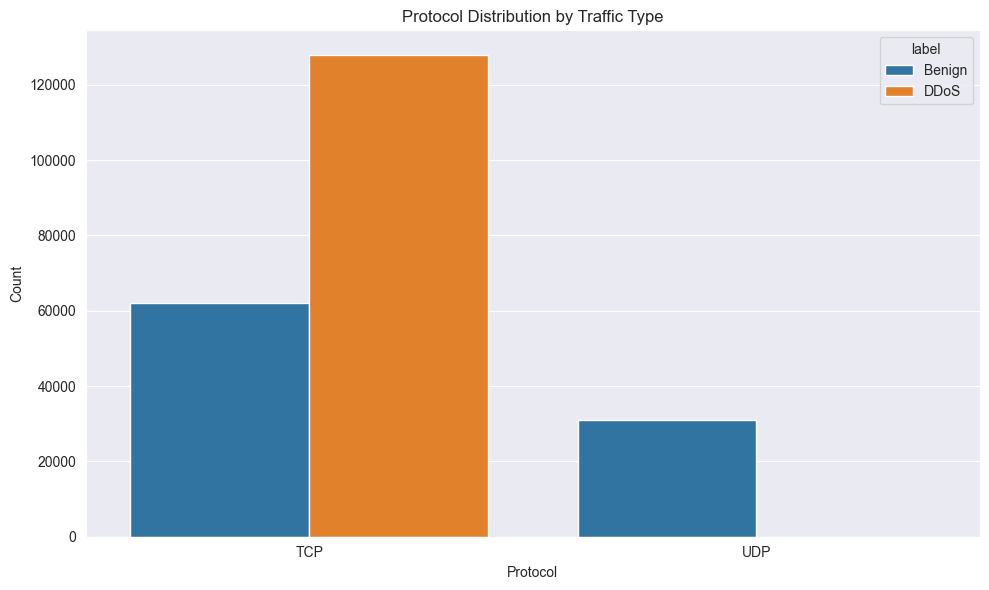

In [58]:
# Map protocol numbers to names for better interpretability
protocol_map = {1: 'ICMP', 6: 'TCP', 17: 'UDP'}
df_full['protocol_name'] = df_full['protocol'].map(protocol_map)

plt.figure(figsize=(10, 6))
sns.countplot(x='protocol_name', data=df_full, hue='label')
plt.title('Protocol Distribution by Traffic Type')
plt.xlabel('Protocol')
plt.ylabel('Count')
plt.tight_layout()

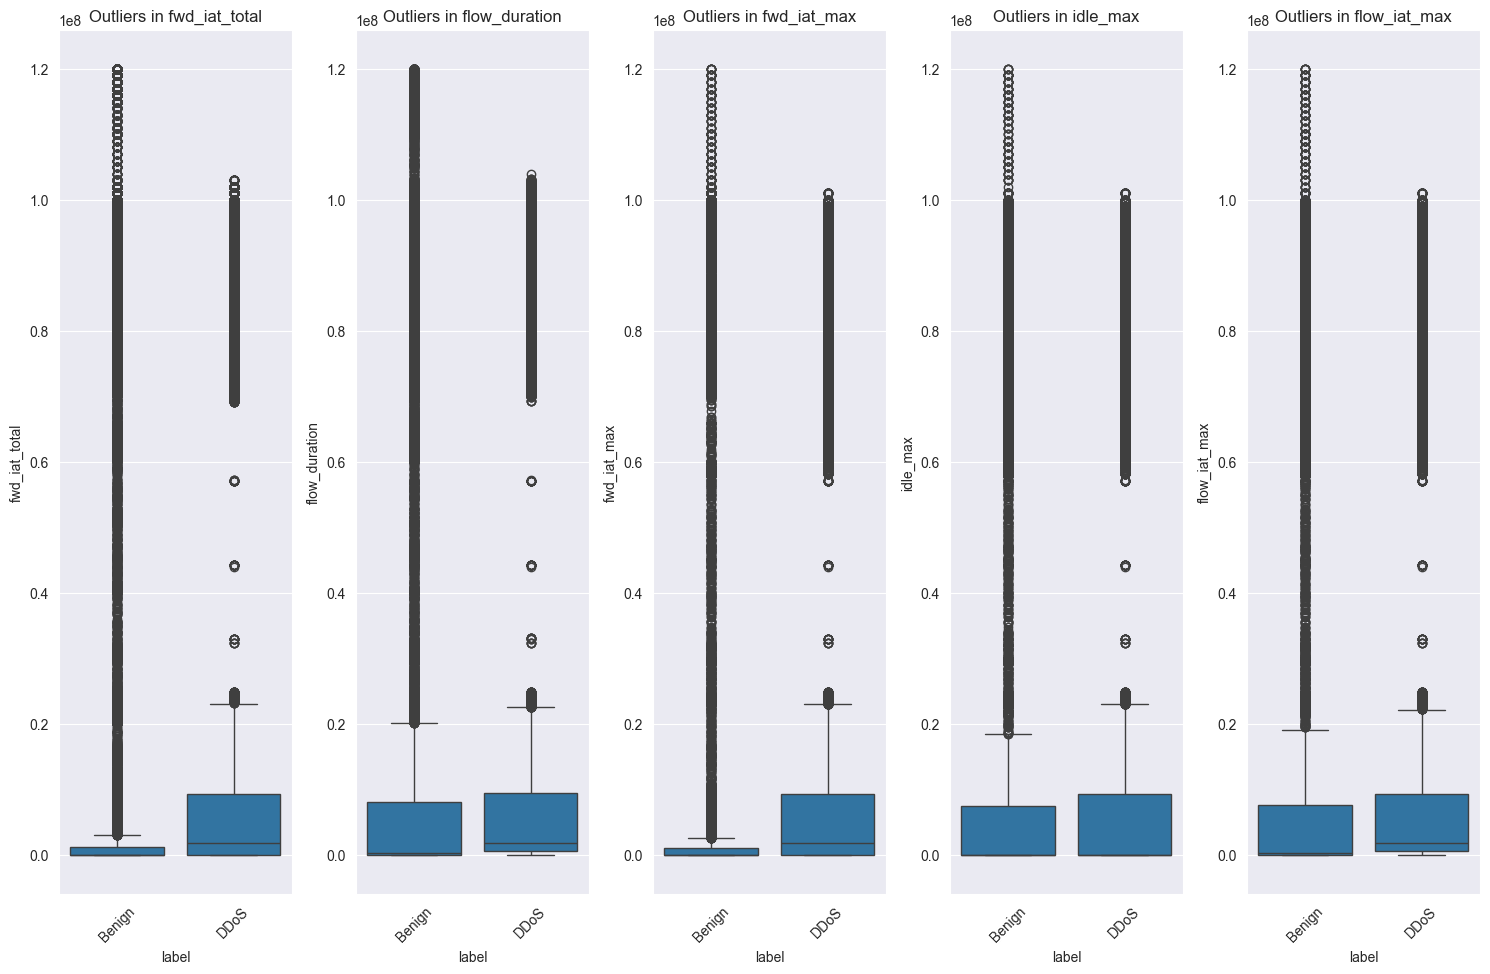

In [59]:
# Outlier visualization
outlier_features = feature_variance['Feature'].head(5).tolist()

plt.figure(figsize=(15, 10))
for i, feature in enumerate(outlier_features):
    plt.subplot(1, 5, i + 1)
    sns.boxplot(x='label', y=feature, data=df_full)
    plt.title(f'Outliers in {feature}')
    plt.xticks(rotation=45)
plt.tight_layout()

In [60]:
# Calculate Z-scores for outlier detection
z_scores = pd.DataFrame()
for feature in outlier_features:
    z_scores[feature] = np.abs(stats.zscore(df_full[feature]))

outlier_counts = []
for feature in outlier_features:
    outliers_benign = ((z_scores[feature] > 3) & (df_full['label'] == 'Benign')).sum()
    outliers_attack = ((z_scores[feature] > 3) & (df_full['label'] == 'DDoS')).sum()
    outlier_counts.append({
        'feature': feature,
        'benign_outliers': outliers_benign,
        'attack_outliers': outliers_attack
    })

for count in outlier_counts:
    print(count['feature'])
    print(f"Outliers in Benign: {count['benign_outliers']}")
    print(f"Outliers in Attack: {count['attack_outliers']}\n")

fwd_iat_total
Outliers in Benign: 3292
Outliers in Attack: 0

flow_duration
Outliers in Benign: 3281
Outliers in Attack: 0

fwd_iat_max
Outliers in Benign: 1724
Outliers in Attack: 776

idle_max
Outliers in Benign: 798
Outliers in Attack: 1519

flow_iat_max
Outliers in Benign: 824
Outliers in Attack: 1522

